In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from sklearn.model_selection import GridSearchCV

In [6]:
url = "https://raw.githubusercontent.com/royhridoy965-sketch/AI-and-ML-Lab/refs/heads/main/knn/Iris.csv"

df = pd.read_csv(url)

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [7]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


,0
Id,0
SepalLengthCm,0
SepalWidthCm,0
PetalLengthCm,0
PetalWidthCm,0
Species,0


In [8]:
imputer = SimpleImputer(strategy='mean')

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = imputer.fit_transform(df[numeric_cols])

In [9]:
le = LabelEncoder()

df['Species'] = le.fit_transform(df['Species'])

df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1.0,5.1,3.5,1.4,0.2,0
1,2.0,4.9,3.0,1.4,0.2,0
2,3.0,4.7,3.2,1.3,0.2,0
3,4.0,4.6,3.1,1.5,0.2,0
4,5.0,5.0,3.6,1.4,0.2,0


In [10]:
X = df.drop(['Id','Species'], axis=1)

y = df['Species']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [13]:
error_rate = []

for k in range(1,21):

    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train,y_train)

    pred = knn.predict(X_test)

    error_rate.append(np.mean(pred != y_test))

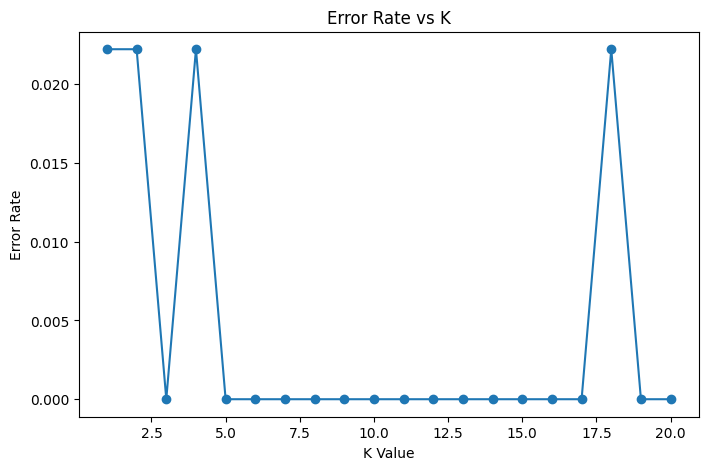

In [14]:
plt.figure(figsize=(8,5))

plt.plot(range(1,21), error_rate, marker='o')

plt.title('Error Rate vs K')

plt.xlabel('K Value')

plt.ylabel('Error Rate')

plt.show()

In [15]:
param_grid = {
    'n_neighbors':[3,5,7,9],
    'weights':['uniform','distance'],
    'metric':['euclidean','manhattan','minkowski']
}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5
)

grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=KNeighborsClassifier(),
             param_grid={'metric': ['euclidean', 'manhattan', 'minkowski'],
                         'n_neighbors': [3, 5, 7, 9],
                         'weights': ['uniform', 'distance']})

In [16]:
print(grid.best_params_)

{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}


In [17]:
{'metric':'euclidean',
'n_neighbors':5,
'weights':'uniform'}

{'metric': 'euclidean', 'n_neighbors': 5, 'weights': 'uniform'}

In [18]:
best_knn = grid.best_estimator_

best_knn.fit(X_train,y_train)

y_pred = best_knn.predict(X_test)

In [19]:
accuracy = accuracy_score(y_test,y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average='weighted'
)

recall = recall_score(
    y_test,
    y_pred,
    average='weighted'
)

f1 = f1_score(
    y_test,
    y_pred,
    average='weighted'
)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1:",f1)

print(classification_report(y_test,y_pred))

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



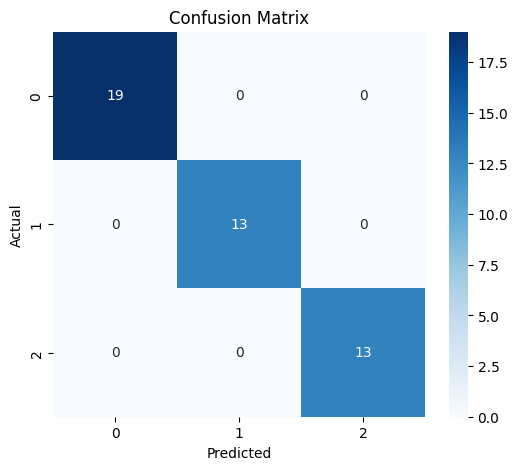

In [20]:
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    fmt='d'
)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.show()

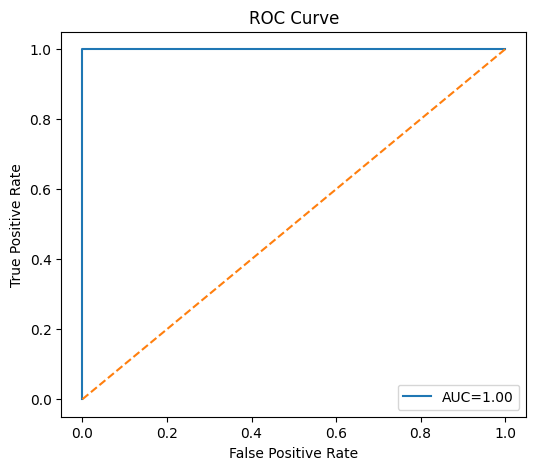

AUC: 1.0


In [21]:
y_prob = best_knn.predict_proba(X_test)

fpr, tpr, _ = roc_curve(
    y_test,
    y_prob[:,1],
    pos_label=1
)

roc_auc = auc(fpr,tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr,tpr,label='AUC=%0.2f'%roc_auc)

plt.plot([0,1],[0,1],'--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.legend()

plt.show()

print("AUC:",roc_auc)

In [22]:
X2 = df.iloc[:,1:3].values
y2 = df['Species'].values

X2_train,X2_test,y2_train,y2_test = train_test_split(
    X2,
    y2,
    test_size=0.3,
    random_state=42
)

scaler2 = StandardScaler()

X2_train = scaler2.fit_transform(X2_train)

knn2 = KNeighborsClassifier(n_neighbors=5)

knn2.fit(X2_train,y2_train)

KNeighborsClassifier()

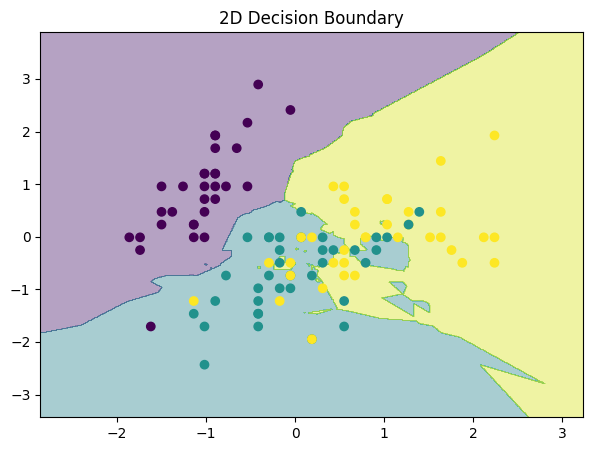

In [23]:
from matplotlib.colors import ListedColormap

x_min,x_max = X2_train[:,0].min()-1, X2_train[:,0].max()+1
y_min,y_max = X2_train[:,1].min()-1, X2_train[:,1].max()+1

xx,yy = np.meshgrid(
    np.arange(x_min,x_max,0.01),
    np.arange(y_min,y_max,0.01)
)

Z = knn2.predict(
    np.c_[xx.ravel(),yy.ravel()]
)

Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))

plt.contourf(
    xx,yy,Z,
    alpha=0.4
)

plt.scatter(
    X2_train[:,0],
    X2_train[:,1],
    c=y2_train
)

plt.title('2D Decision Boundary')

plt.show()